In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
cars = pd.read_csv("../data/used_cars_cleaned.csv")

In [57]:
cars

,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,make
0,0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi
...,...,...,...,...,...,...,...,...,...,...,...
97141,97141,Eos,2012,5990,Manual,74000,Diesel,125,58.9,2.0,Volkswagen
97142,97142,Fox,2008,1799,Manual,88102,Petrol,145,46.3,1.2,Volkswagen
97143,97143,Fox,2009,1590,Manual,70000,Petrol,200,42.0,1.4,Volkswagen
97144,97144,Fox,2006,1250,Manual,82704,Petrol,150,46.3,1.2,Volkswagen


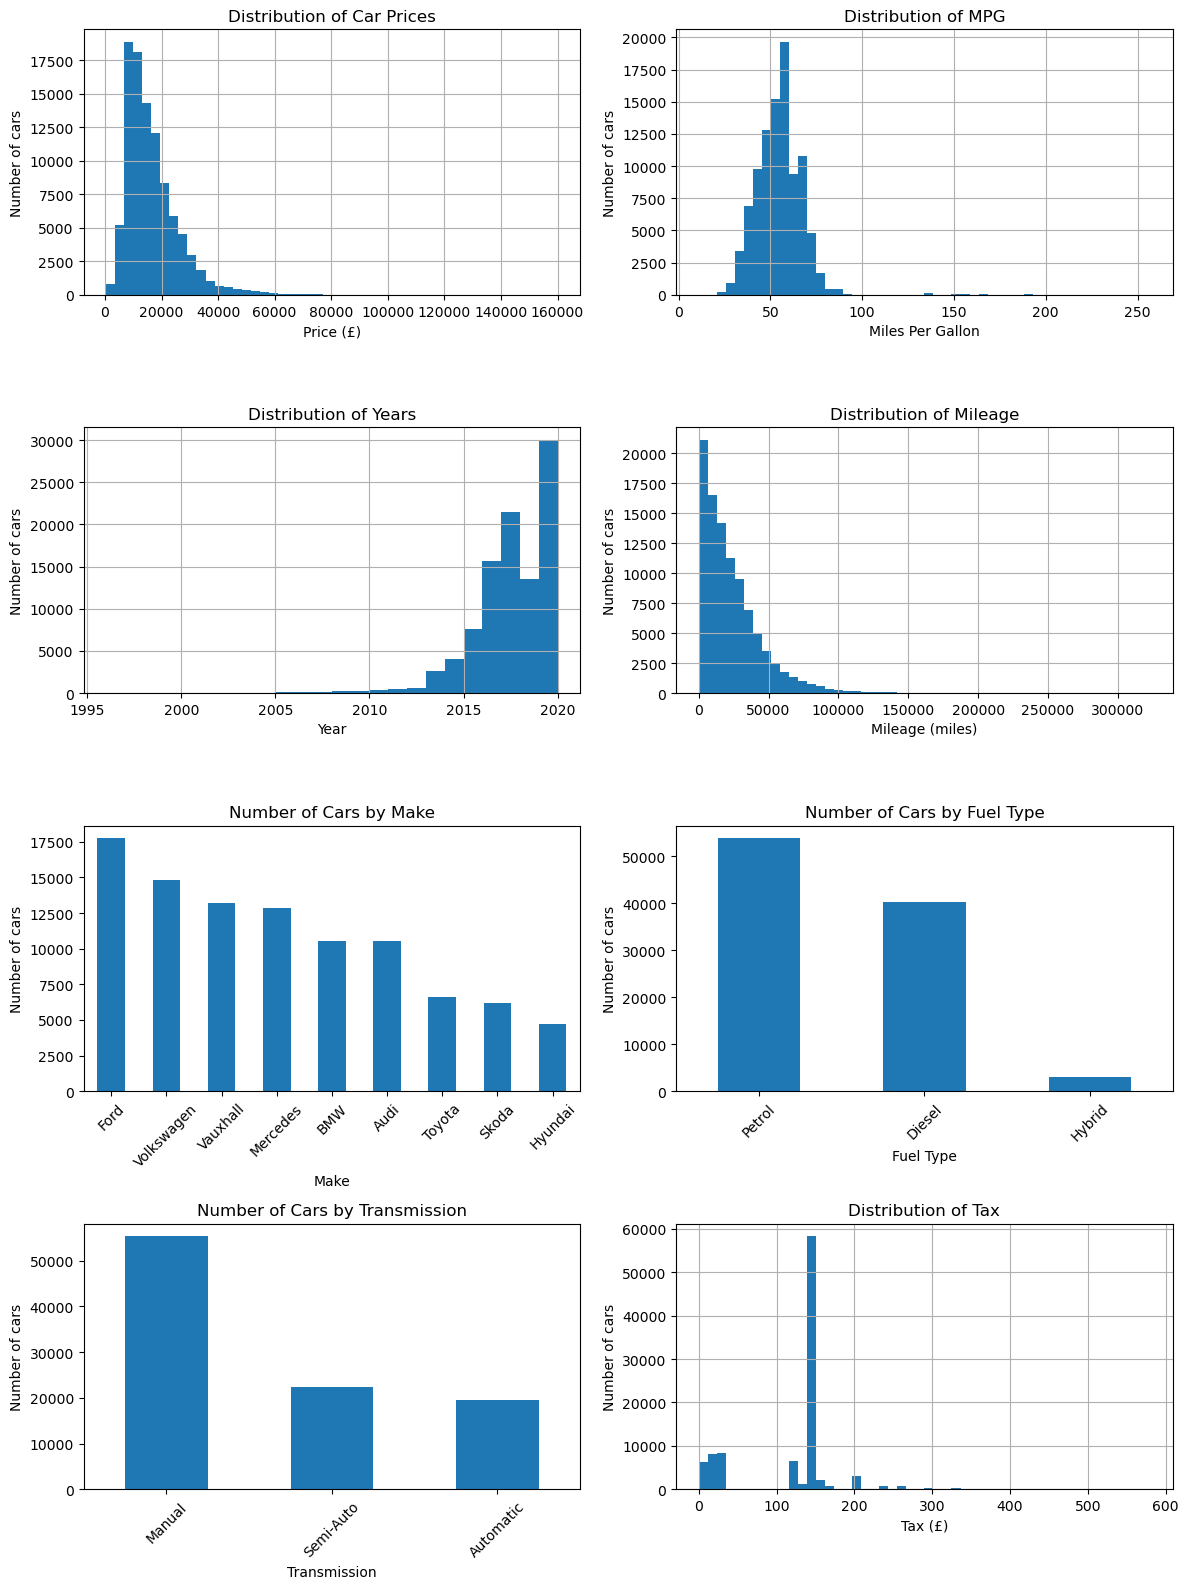

<Figure size 640x480 with 0 Axes>

In [92]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

cars["price"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Number of cars")
axes[0, 0].set_title("Distribution of Car Prices")

cars["mpg"].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_xlabel("Miles Per Gallon")
axes[0, 1].set_ylabel("Number of cars")
axes[0, 1].set_title("Distribution of MPG")

cars["year"].hist(bins=24, ax=axes[1, 0])
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number of cars")
axes[1, 0].set_title("Distribution of Years")

cars["mileage"].hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_xlabel("Mileage (miles)")
axes[1, 1].set_ylabel("Number of cars")
axes[1, 1].set_title("Distribution of Mileage")

cars["make"].value_counts().plot(
    kind="bar",
    ax=axes[2, 0]
)

axes[2, 0].set_xlabel("Make")
axes[2, 0].set_ylabel("Number of cars")
axes[2, 0].set_title("Number of Cars by Make")
axes[2, 0].tick_params(axis="x", rotation=45)

cars["fuelType"].value_counts().plot(
    kind="bar",
    ax=axes[2, 1]
)
# Transmission
cars["transmission"].value_counts().plot(
    kind="bar",
    ax=axes[3, 0]
)
axes[2, 1].set_xlabel("Fuel Type")
axes[2, 1].set_ylabel("Number of cars")
axes[2, 1].set_title("Number of Cars by Fuel Type")
axes[2, 1].tick_params(axis="x", rotation=45)

axes[3, 0].set_xlabel("Transmission")
axes[3, 0].set_ylabel("Number of cars")
axes[3, 0].set_title("Number of Cars by Transmission")
axes[3, 0].tick_params(axis="x", rotation=45)

# Tax
cars["tax"].hist(bins=50, ax=axes[3, 1])
axes[3, 1].set_xlabel("Tax (£)")
axes[3, 1].set_ylabel("Number of cars")
axes[3, 1].set_title("Distribution of Tax")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### Exploratory Data Analysis

The dataset is dominated by lower-priced vehicles, with the price distribution strongly right-skewed. Most cars are priced below approximately £30,000, although a small number of substantially more expensive vehicles create a long upper tail.

Most vehicles achieve around 40–70 MPG, with a small number of extreme values above 100 MPG. The dataset is also heavily weighted towards newer vehicles, particularly those registered from around 2015 onwards.

Mileage is strongly right-skewed, with most cars having relatively low mileage and progressively fewer vehicles at higher mileages. A small number of cars have exceptionally high mileage.

The dataset is not evenly distributed across manufacturers. Ford and Volkswagen are the most common makes, while Vauxhall is the least represented among those included. Petrol and diesel vehicles account for the vast majority of the dataset, with relatively few hybrid vehicles. These imbalances should be considered when evaluating model performance, as predictions may be more reliable for well-represented categories.

There is also an imbalance in transmission types. Manual vehicles account for the majority of observations, with substantially fewer semi-automatic and automatic vehicles. This should also be considered when assessing model performance across different vehicle categories.

Vehicle tax is concentrated around a relatively small number of discrete values rather than being continuously distributed, with a particularly large concentration around £145–£150. Smaller groups of vehicles occur at lower and higher tax values, while relatively few observations have very high tax. This suggests that tax behaves more like a variable with distinct bands within the dataset than a smoothly distributed continuous feature.

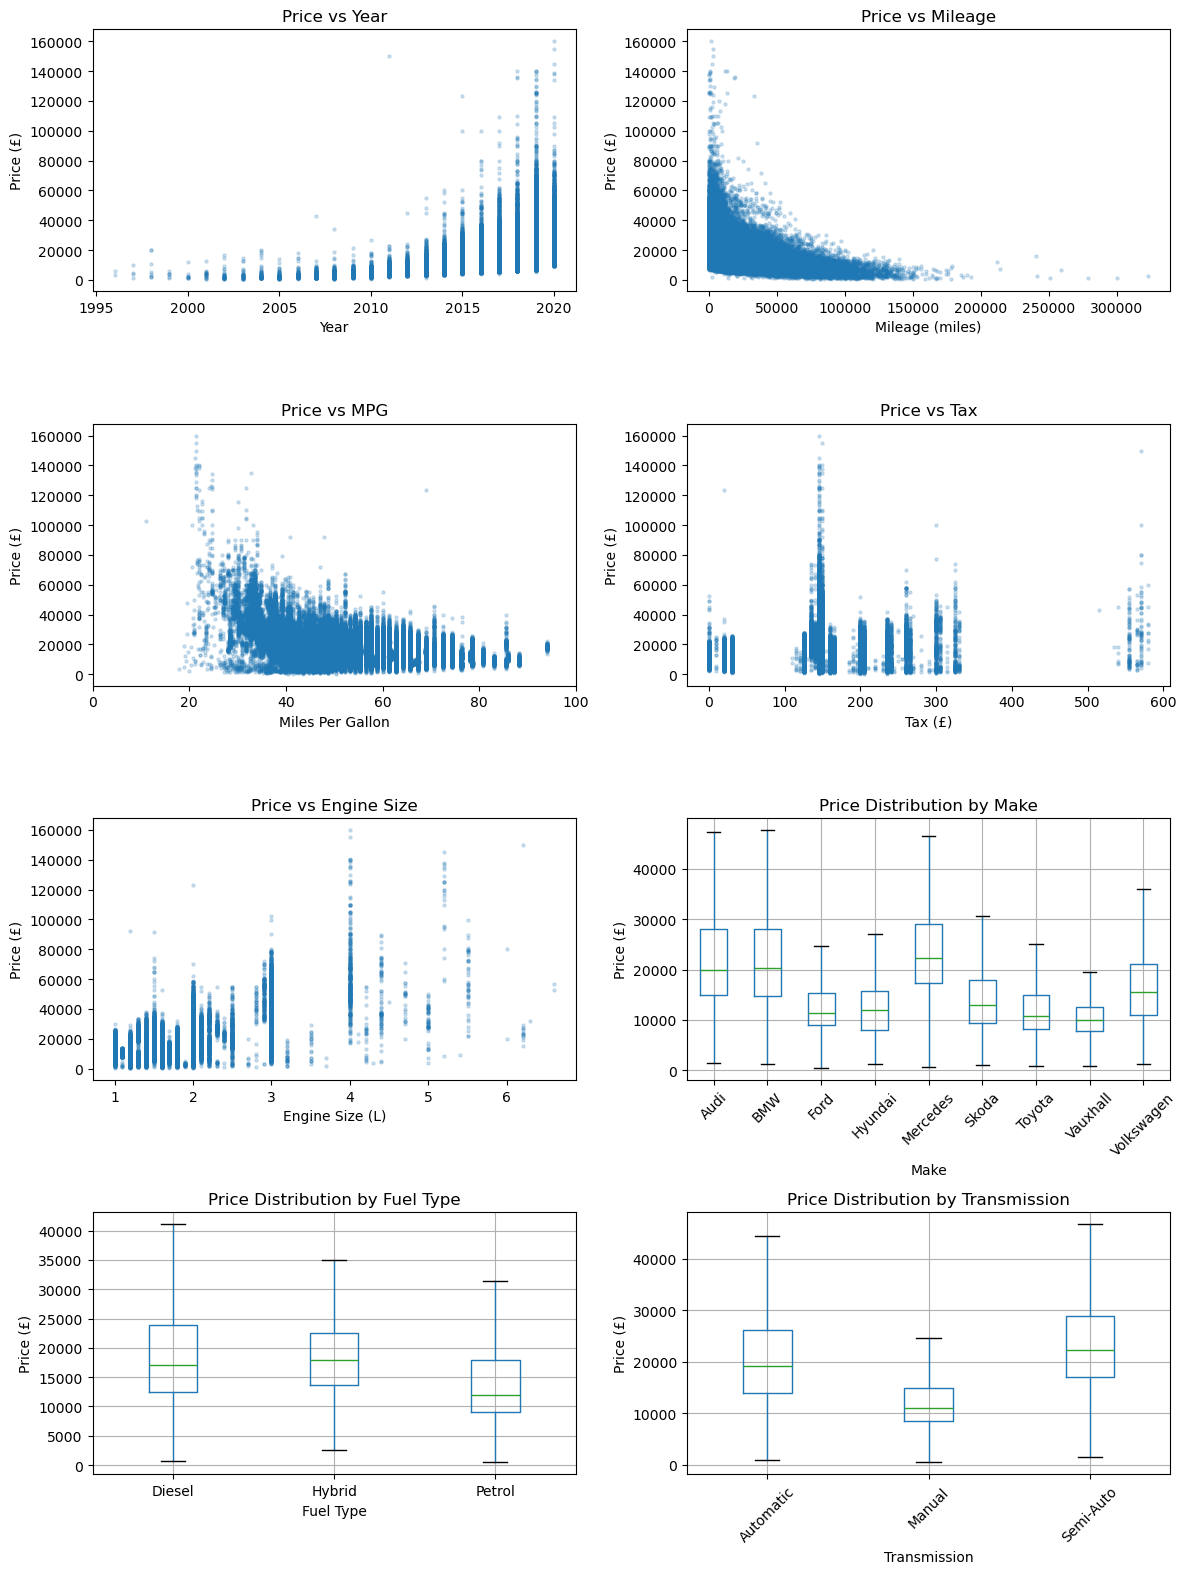

In [85]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# Price vs Year
axes[0, 0].scatter(cars["year"], cars["price"], alpha=0.2, s=5)
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Price (£)")
axes[0, 0].set_title("Price vs Year")

# Price vs Mileage
axes[0, 1].scatter(cars["mileage"], cars["price"], alpha=0.2, s=5)
axes[0, 1].set_xlabel("Mileage (miles)")
axes[0, 1].set_ylabel("Price (£)")
axes[0, 1].set_title("Price vs Mileage")

# Price vs MPG
axes[1, 0].scatter(cars["mpg"], cars["price"], alpha=0.2, s=5)
axes[1, 0].set_xlabel("Miles Per Gallon")
axes[1, 0].set_ylabel("Price (£)")
axes[1, 0].set_title("Price vs MPG")
axes[1, 0].set_xlim(0, 100)

# Price vs Tax
axes[1, 1].scatter(cars["tax"], cars["price"], alpha=0.2, s=5)
axes[1, 1].set_xlabel("Tax (£)")
axes[1, 1].set_ylabel("Price (£)")
axes[1, 1].set_title("Price vs Tax")

# Price vs Engine Size
axes[2, 0].scatter(cars["engineSize"], cars["price"], alpha=0.2, s=5)
axes[2, 0].set_xlabel("Engine Size (L)")
axes[2, 0].set_ylabel("Price (£)")
axes[2, 0].set_title("Price vs Engine Size")

# Price by Make
cars.boxplot(
    column="price",
    by="make",
    ax=axes[2, 1],
    showfliers=False
)
axes[2, 1].set_xlabel("Make")
axes[2, 1].set_ylabel("Price (£)")
axes[2, 1].set_title("Price Distribution by Make")
axes[2, 1].tick_params(axis="x", rotation=45)

# Price by Fuel Type
cars.boxplot(
    column="price",
    by="fuelType",
    ax=axes[3, 0],
    showfliers=False
)
axes[3, 0].set_xlabel("Fuel Type")
axes[3, 0].set_ylabel("Price (£)")
axes[3, 0].set_title("Price Distribution by Fuel Type")

# Price by Transmission
cars.boxplot(
    column="price",
    by="transmission",
    ax=axes[3, 1],
    showfliers=False
)
axes[3, 1].set_xlabel("Transmission")
axes[3, 1].set_ylabel("Price (£)")
axes[3, 1].set_title("Price Distribution by Transmission")
axes[3, 1].tick_params(axis="x", rotation=45)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Relationships Between Features and Price

The plots show several clear relationships between the explanatory variables and vehicle price. **Year has a strong positive relationship with price**, with newer cars generally commanding higher prices. The range of prices also increases considerably for newer vehicles, reflecting the presence of newer premium and high-performance models.

**Mileage has a strong negative relationship with price.** Cars with lower mileage span a wide range of prices, whereas high-mileage vehicles are overwhelmingly concentrated at lower prices. The relationship appears nonlinear, with price declining particularly rapidly over the lower mileage range before gradually flattening.

**MPG also shows a negative association with price**, although the relationship is considerably more dispersed. The original MPG distribution contained a small number of extreme values above 100 MPG, which compressed the majority of observations into a relatively narrow section of the plot. The x-axis was therefore restricted to 0–100 MPG for this visualisation to make the relationship within the main body of the data clearer. These higher-MPG observations were not removed from the dataset.

**Tax shows a more complex relationship with price.** Vehicles are concentrated at several discrete tax values rather than being continuously distributed, producing the vertical bands visible in the plot. There is no simple linear relationship between tax and price, although some tax bands contain a greater proportion of higher-priced vehicles.

**Engine size is generally positively associated with price**, with larger-engine vehicles tending to command higher prices. However, there is substantial variation within each engine size, suggesting that other characteristics such as make, model, age and mileage also play an important role.

**Make has a clear relationship with vehicle price**. Premium manufacturers such as Mercedes, BMW and Audi have substantially higher median prices than manufacturers such as Ford, Toyota and Vauxhall. There is also considerable variation within each manufacturer. Overall, the plots suggest that year, mileage, engine size and make are likely to be particularly informative predictors of vehicle price, while MPG and tax exhibit more complex relationships.

**Fuel type also appears to be associated with price.** Hybrid vehicles have the highest median price, followed closely by diesel vehicles, while petrol vehicles have a noticeably lower median price. However, there is substantial overlap between the price distributions, so fuel type alone does not determine vehicle price.

**Transmission type shows a clearer difference in price distributions.** Semi-automatic vehicles have the highest median price, followed by automatic vehicles, while manual vehicles are considerably cheaper on average. This suggests that transmission type may provide useful predictive information for the model. However, these differences may partly reflect other characteristics of the vehicles, such as make, model, age and engine size, rather than the effect of transmission type alone.

In [82]:
numeric_cols = [
    "price",
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize"
]

cars[numeric_cols].corr()

,price,year,mileage,tax,mpg,engineSize
price,1.000000,0.494942,-0.418272,0.307652,-0.359352,0.648397
year,0.494942,1.000000,-0.744353,0.193533,-0.151631,-0.036968
mileage,-0.418272,-0.744353,1.000000,-0.215082,0.212134,0.107886
tax,0.307652,0.193533,-0.215082,1.000000,-0.524156,0.283894
mpg,-0.359352,-0.151631,0.212134,-0.524156,1.000000,-0.267802
engineSize,0.648397,-0.036968,0.107886,0.283894,-0.267802,1.000000


### Correlation Analysis

The correlation matrix supports several of the relationships observed in the scatter plots. **Engine size has the strongest positive linear correlation with price (0.65)**, followed by **year (0.49)**. This suggests that newer vehicles and those with larger engines tend to be more expensive.

**Mileage (-0.42)** and **MPG (-0.36)** are moderately negatively correlated with price, indicating that higher-mileage and more fuel-efficient vehicles tend to have lower prices in this dataset. **Tax has a weaker positive correlation with price (0.31)**.

There are also notable relationships between the predictor variables themselves. In particular, **year and mileage are strongly negatively correlated (-0.74)**, which is expected as newer cars generally have accumulated fewer miles. Tax and MPG also have a moderately strong negative correlation (-0.52).

These correlations only measure **linear relationships** and do not imply causation. The earlier scatter plots indicate that several relationships, particularly mileage and tax against price, are nonlinear. Therefore, correlation coefficients alone do not capture all of the predictive information contained within these features.